In [1]:
import pandas as pd
import ir_datasets
from src.data import DATA_DIR_INTERIM
from topic_gen.evaluate import QrelsEvaluator, CohenKappa, MeanAverageError, AreaUnderReceiver, binarize_qrels
from src.data import load_qrels_from_path
from src.utils import format_score
from topic_gen import logger
logger.setLevel("DEBUG")

### Binary Relevance Labels

In [2]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_INTERIM / "robust-topics-qrels"
predictions, names, metadata = load_qrels_from_path(BASE_DIR)

# binarize qrels
predictions = [binarize_qrels(qrels) for qrels in predictions]

In [3]:
# Evaluate qrels
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=binarize_qrels(ir_datasets.load(
        "disks45/nocr/trec-robust-2004").qrels_iter()),
    measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
    bootstrap=20,
    names=names)

[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 11/2940 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 6/2945 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 11/2940 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 9/2942 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 9/2942 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 8/2943 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 9/2942 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 6/2945 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 8/2943 qrels in references but not in predictions.
[topic_gen] [WARNING] (evaluate.py:345) Miss

In [4]:
df = pd.DataFrame(res)
df["score"] = df.apply(format_score, axis=1)
df = df.pivot(index="name", columns="measure", values="score").reset_index()

In [5]:
df = df.merge(metadata, left_on="name", right_on="date")

In [6]:
df

,name,AreaUnderReceiver,CohenKappa,MeanAverageError,date,model,data,prompt,k,output,...,topics_date,topics_model,topics_data,topics_prompt,topics_k,topics_nqueries,topics_ndocspos,topics_ndocsneg,topics_output,topics_task
0,2025-11-25_17:40:33,0.89 ± 0.01,0.74 ± 0.02,0.11 ± 0.01,2025-11-25_17:40:33,qwen3-30B-no-think,robust,-DNA-zero-shot,None,/workspaces/conf26-generating-topics/data/inte...,...,2025-11-25_17:40:33,None,robust,human,None,None,None,None,/workspaces/conf26-generating-topics/data/inte...,topics
1,2025-11-25_17:46:19,0.89 ± 0.01,0.75 ± 0.02,0.11 ± 0.01,2025-11-25_17:46:19,qwen3-30B-no-think,robust,-DNA-zero-shot,None,/workspaces/conf26-generating-topics/data/inte...,...,2025-11-25_17:46:19,None,robust,human,None,None,None,None,/workspaces/conf26-generating-topics/data/inte...,topics
2,2025-11-25_17:52:03,0.89 ± 0.01,0.75 ± 0.02,0.11 ± 0.01,2025-11-25_17:52:03,qwen3-30B-no-think,robust,-DNA-zero-shot,None,/workspaces/conf26-generating-topics/data/inte...,...,2025-11-25_17:52:03,None,robust,human,None,None,None,None,/workspaces/conf26-generating-topics/data/inte...,topics
3,2025-11-25_17:57:49,0.89 ± 0.01,0.75 ± 0.02,0.11 ± 0.01,2025-11-25_17:57:49,qwen3-30B-no-think,robust,-DNA-zero-shot,None,/workspaces/conf26-generating-topics/data/inte...,...,2025-11-25_17:57:49,None,robust,human,None,None,None,None,/workspaces/conf26-generating-topics/data/inte...,topics
4,2025-11-25_18:03:36,0.89 ± 0.01,0.74 ± 0.02,0.11 ± 0.01,2025-11-25_18:03:36,qwen3-30B-no-think,robust,-DNA-zero-shot,None,/workspaces/conf26-generating-topics/data/inte...,...,2025-11-25_18:03:36,None,robust,human,None,None,None,None,/workspaces/conf26-generating-topics/data/inte...,topics
5,2025-11-25_18:09:24,0.90 ± 0.01,0.75 ± 0.03,0.11 ± 0.01,2025-11-25_18:09:24,qwen3-30B-no-think,robust,-DNA-zero-shot,None,/workspaces/conf26-generating-topics/data/inte...,...,2025-11-25_18:09:24,None,robust,human,None,None,None,None,/workspaces/conf26-generating-topics/data/inte...,topics
6,2025-11-25_18:15:14,0.90 ± 0.01,0.75 ± 0.02,0.11 ± 0.01,2025-11-25_18:15:14,qwen3-30B-no-think,robust,-DNA-zero-shot,None,/workspaces/conf26-generating-topics/data/inte...,...,2025-11-25_18:15:14,None,robust,human,None,None,None,None,/workspaces/conf26-generating-topics/data/inte...,topics
7,2025-11-25_18:20:56,0.90 ± 0.01,0.75 ± 0.03,0.11 ± 0.01,2025-11-25_18:20:56,qwen3-30B-no-think,robust,-DNA-zero-shot,None,/workspaces/conf26-generating-topics/data/inte...,...,2025-11-25_18:20:56,None,robust,human,None,None,None,None,/workspaces/conf26-generating-topics/data/inte...,topics
8,2025-11-25_18:26:46,0.90 ± 0.01,0.75 ± 0.02,0.10 ± 0.01,2025-11-25_18:26:46,qwen3-30B-no-think,robust,-DNA-zero-shot,None,/workspaces/conf26-generating-topics/data/inte...,...,2025-11-25_18:26:46,None,robust,human,None,None,None,None,/workspaces/conf26-generating-topics/data/inte...,topics
9,2025-11-25_18:32:30,0.89 ± 0.01,0.75 ± 0.02,0.11 ± 0.01,2025-11-25_18:32:30,qwen3-30B-no-think,robust,-DNA-zero-shot,None,/workspaces/conf26-generating-topics/data/inte...,...,2025-11-25_18:32:30,None,robust,human,None,None,None,None,/workspaces/conf26-generating-topics/data/inte...,topics


## Alignment
RQ: How well align qrels based on generated topics with the original qrels?
 

### Prompting Strategies
**Important:** the columns `ndocpos` and `ndocsneg` state values even if they are ignored by the prompts.


Prompts:
- Trec: query variants and relevant docs
- trec-query: only query
- trec-contrastive: query, relevant, and irelevant documents
  

### Findings
- Judgments based on the original topics are always better. Sometimes just a little!
- Some settings show a substantial drop in alignment, for example, for `qwen3-30B` on generated topics with the `trec` prompt with one query variant and one relevant document, the Cohen's $\kappa$ agreement to human labels drops from the substantial agreement of 0.75 to a moderate agreement of 0.52.
- More context always helps.
- Contrastive prompting is the best.

In [25]:
model = "qwen3-30B-no-think"  # df["model"]
prompt_sorter = [
    "human",            # Original topic
    "trec-query",       # Original topic title field
    "trec",             # Query variants + relevant documents
    "trec-contrastive",  # Query variants + relevant + non-relevant documents
    'trec-docs-rel',     # relevant documents
    'trec-docs',        # relevant + non-relevant documents
]
df["topics_prompt"] = pd.Categorical(df["topics_prompt"], prompt_sorter)

df[(df["prompt"] == "-DNA-zero-shot") & \
      (df["model"] == model) &
   ((df["model"] == df["topics_model"]) | (df["topics_model"] == "trec assessors"))] \
    .sort_values(by=["model", "topics_prompt"], ascending=[True, True])[["name", "topics_time", "topics_prompt", "model", "topics_nqueries", "topics_ndocspos", "topics_ndocsneg", "CohenKappa", "MeanAverageError", "AreaUnderReceiver"]]

KeyError: "['topics_time'] not in index"

## Plot 

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
def plot_context_sweep(df, topic_prompt: str, measure: str = "CohenKappa"):
    # prepare data
    df_orig = df[df["topics_model"] == "trec assessors"]

    df = df[
        (df["prompt"] == "-DNA-zero-shot") & ((df["model"] == df["topics_model"]) | (df["topics_model"] == "trec assessors"))]\
        .sort_values(by=["model", "topics_prompt"], ascending=[True, True])[["topics_prompt", "model", "topics_nqueries", "topics_ndocspos", "topics_ndocsneg", "CohenKappa", "MeanAverageError", "AreaUnderReceiver"]]

    df = df[(df["topics_prompt"] == topic_prompt)]
    df[measure] = df[measure].apply(lambda s: float(s.split(" ± ")[0]))

    # plot
    sns.lineplot(data=df, x="topics_nqueries", y=measure,
                 hue="model", markers=True, dashes=False)

    # original topics as dashed lines
    for _, row in df_orig.iterrows():
        plt.axhline(y=float(row[measure].split(" ± ")[0]),
                    linestyle='--', label=f"Original - {row['model']}")
    plt.legend()

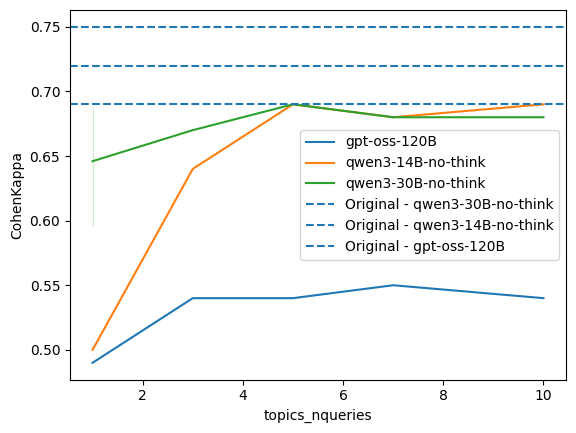

In [16]:
plot_context_sweep(df, topic_prompt="trec-contrastive")

### Per-Topic

In [17]:
# Load generated qrels from path
BASE_DIR = DATA_DIR_INTERIM / "robust-gen-topic-qrels"  # "generated_qrels"
predictions, names, metadata = load_qrels_from_path(BASE_DIR)

# binarize qrels
predictions = [binarize_qrels(qrels) for qrels in predictions]

[topic_gen] [WARNING] (data.py:55) Metadata not found for result 2025-11-18_13:58:17, skipping...


In [18]:
# Evaluate qrels
res = QrelsEvaluator.experiment(
    predictions=predictions,
    references=binarize_qrels(ir_datasets.load(
        "disks45/nocr/trec-robust-2004").qrels_iter()),
    measures=[CohenKappa(), MeanAverageError(), AreaUnderReceiver()],
    # bootstrap=20,
    per_query=True,
    names=names)

[topic_gen] [WARNING] (evaluate.py:345) Missing qrels: 7/2944 qrels in references but not in predictions.
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/vscode/.cache/pypoetry/virtualenvs/src-B2WAz2j2-py3.11/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class 

In [20]:
df = pd.DataFrame(res)

In [24]:
summary = df.groupby(["topic_id", "measure"])["value"].describe().reset_index()

In [30]:
summary[summary["measure"] == "CohenKappa"].sort_values(by="mean", ascending=True)

,topic_id,measure,count,mean,std,min,25%,50%,75%,max
136,346,CohenKappa,154.0,-0.050969,0.160193,-0.241379,-0.200000,-0.125000,0.068966,0.400000
742,700,CohenKappa,151.0,-0.022844,0.020385,-0.038339,-0.034775,-0.028571,-0.025316,0.078891
445,449,CohenKappa,154.0,0.011827,0.085071,-0.285714,0.000000,0.000000,0.000000,0.571429
448,450,CohenKappa,154.0,0.029653,0.145534,-0.111111,-0.080000,-0.058824,0.136986,0.640000
199,367,CohenKappa,154.0,0.046039,0.104425,-0.157895,0.000000,0.000000,0.090909,0.454545
...,...,...,...,...,...,...,...,...,...,...
685,681,CohenKappa,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
712,690,CohenKappa,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
715,691,CohenKappa,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
724,694,CohenKappa,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
df[df["topic_id"] == "309"]

,topic_id,measure,value,name
24,309,CohenKappa,NaN,2025-11-21_01:43:20
25,309,MeanAverageError,0.0,2025-11-21_01:43:20
26,309,AreaUnderReceiver,NaN,2025-11-21_01:43:20
768,309,CohenKappa,NaN,2025-11-18_13:12:27
769,309,MeanAverageError,0.0,2025-11-18_13:12:27
...,...,...,...,...
112951,309,MeanAverageError,0.0,2025-11-19_18:22:09
112952,309,AreaUnderReceiver,NaN,2025-11-19_18:22:09
113694,309,CohenKappa,NaN,2025-11-18_15:59:23
113695,309,MeanAverageError,0.0,2025-11-18_15:59:23
